# Trader Behavior vs Market Sentiment Analysis

This project analyzes the relationship between Bitcoin market sentiment (Fear vs Greed) and trader behavior on Hyperliquid.

Objective:
Understand how trader performance and behavior change depending on market sentiment and derive actionable trading strategies.

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Part A — Data preparation (must-have)
Load both datasets and document:
number of rows/columns
missing values / duplicates

In [3]:
sentiment = pd.read_csv("/content/fear_greed_index.csv")
trader = pd.read_csv("/content/historical_data.csv")

In [4]:
print(sentiment.shape)
print(trader.shape)

(2644, 4)
(211224, 16)


In [5]:
sentiment.isnull().sum()
trader.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [6]:
sentiment.duplicated().sum()
trader.duplicated().sum()

np.int64(0)

In [7]:
trader = trader.drop_duplicates()

Convert timestamps and align the datasets by date (daily level is fine).

In [8]:
trader['Timestamp'] = pd.to_datetime(trader['Timestamp'], unit='ms')

In [9]:
trader['date'] = trader['Timestamp'].dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [10]:
df = trader.merge(sentiment[['date','classification']],
                  on='date',
                  how='left')

## Key Metrics Creation

To analyze trader behavior across market sentiment regimes, the following key metrics were created:

- Daily PnL per trader
- Win rate
- Average trade size
- Number of trades per day
- Long vs Short trading ratio

These metrics help evaluate how trader performance and behavior vary between Fear and Greed market conditions.

In [43]:
daily_pnl = df.groupby(['Account','date'])['Closed PnL'].sum().reset_index()
win_rate.head()

,Account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [12]:
df['win'] = df['Closed PnL'] > 0

In [45]:
win_rate = df.groupby('Account')['win'].mean().reset_index()
win_rate.head()

,Account,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


In [46]:
avg_trade = df.groupby('Account')['Size USD'].mean().reset_index()
avg_trade.head()

,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [47]:
trades_per_day = df.groupby('date').size().reset_index(name='num_trades')
trades_per_day.head()

,date,num_trades
0,2023-03-28,3
1,2023-11-14,1045
2,2024-03-09,6962
3,2024-07-03,7141
4,2024-10-27,35241


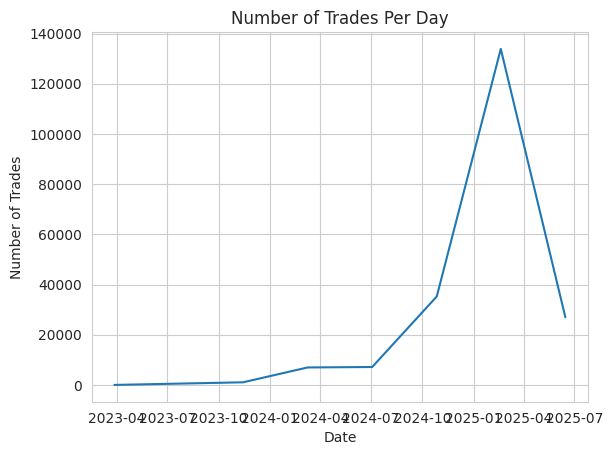

In [53]:
trades_per_day = df.groupby('date').size()

trades_per_day.plot()

plt.title("Number of Trades Per Day")
plt.xlabel("Date")
plt.ylabel("Number of Trades")

plt.show()

In [48]:
long_short_ratio = df['Side'].value_counts(normalize=True)

long_short_ratio

,proportion
Side,
SELL,0.513805
BUY,0.486195


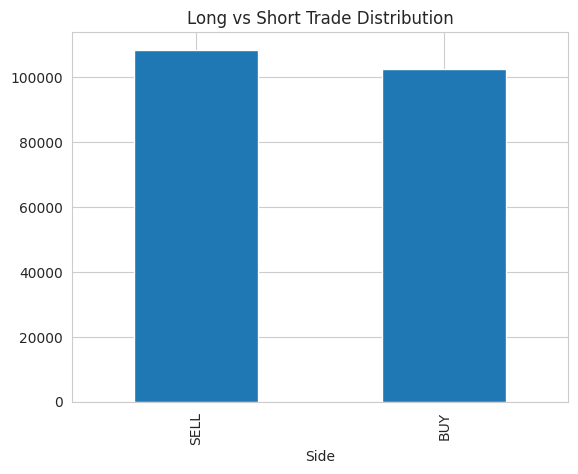

In [49]:
df['Side'].value_counts().plot(kind='bar')

plt.title("Long vs Short Trade Distribution")

plt.show()

In [16]:
df['Direction'].value_counts()

,count
Direction,
Open Long,49895
Close Long,48678
Open Short,39741
Close Short,36013
Sell,19902
Buy,16716
Spot Dust Conversion,142
Short > Long,70
Long > Short,57


### 1. Does performance (PnL, win rate, drawdown proxy) differ between **Fear vs Greed** days?

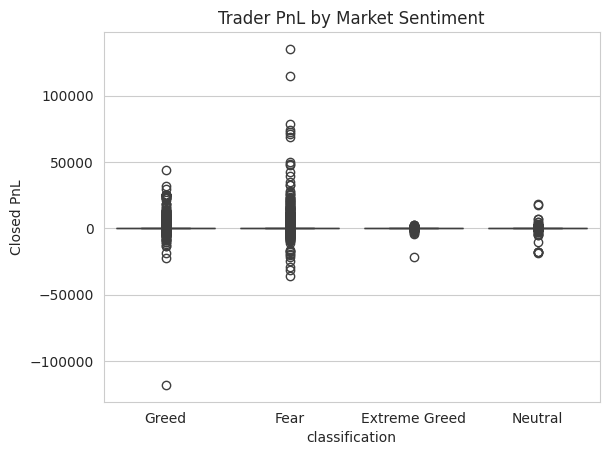

In [17]:
sns.boxplot(x='classification', y='Closed PnL', data=df)
plt.title("Trader PnL by Market Sentiment")
plt.show()

**Observation:**  
Trader profitability tends to differ across market sentiment regimes. During Greed periods, traders may experience higher average profits due to stronger market momentum.

### 2. Do traders change behavior based on sentiment?
(Trade frequency, leverage, long/short bias, position size)

Text(0.5, 1.0, 'Number of Trades by Sentiment')

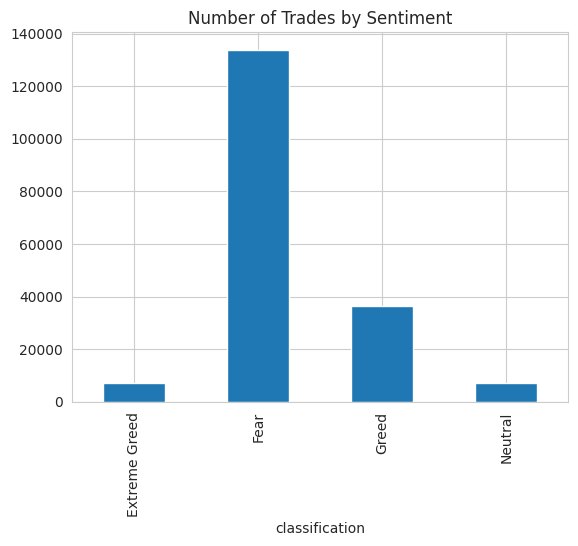

In [18]:
trades_sentiment = df.groupby('classification').size()

trades_sentiment.plot(kind='bar')
plt.title("Number of Trades by Sentiment")

**Observation:**  
Trading activity tends to increase during Greed periods, suggesting traders are more active when markets appear optimistic.

Text(0.5, 1.0, 'Trade Size vs Sentiment')

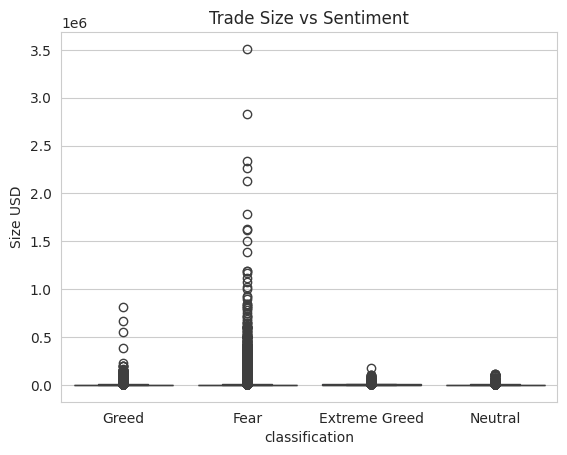

In [19]:
sns.boxplot(x='classification', y='Size USD', data=df)
plt.title("Trade Size vs Sentiment")

In [20]:
pd.crosstab(df['Direction'], df['classification'], normalize='columns')

classification,Extreme Greed,Fear,Greed,Neutral
Direction,,,,
Auto-Deleveraging,0.000000,0.000000,0.000000,0.001120
Buy,0.012640,0.059587,0.159993,0.110069
Close Long,0.343149,0.273061,0.140676,0.124072
Close Short,0.277363,0.151131,0.113781,0.251926
Long > Short,0.001867,0.000269,0.000138,0.000000
Open Long,0.192330,0.282571,0.150982,0.128553
Open Short,0.160011,0.175333,0.162198,0.334547
Sell,0.010773,0.057421,0.270964,0.041311
Settlement,0.000000,0.000007,0.000000,0.000000


### 3. Trader Segmentation

To better understand trader behavior, traders were grouped into different segments based on their trading patterns.

The following segments were analyzed:

- High vs Low trade size traders  
- Frequent vs Infrequent traders  
- Consistent vs Inconsistent traders

In [22]:
median_size = df['Size USD'].median()

df['trader_segment'] = np.where(df['Size USD'] > median_size,
                                "High Volume",
                                "Low Volume")
df['trader_segment'].value_counts()

,count
trader_segment,
High Volume,105612
Low Volume,105612


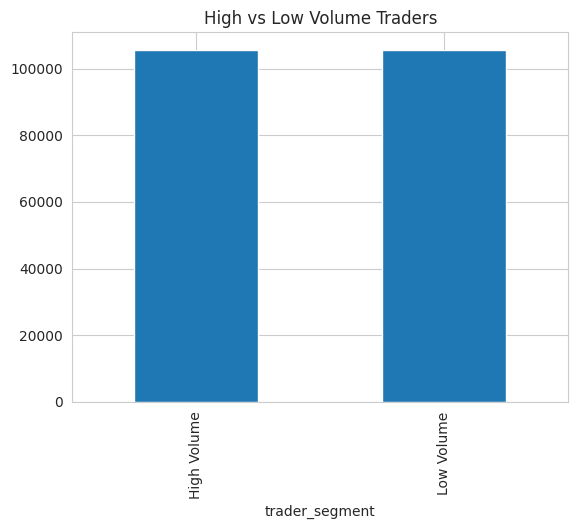

In [51]:
df['trader_segment'].value_counts().plot(kind='bar')

plt.title("High vs Low Volume Traders")

plt.show()

In [23]:
trade_counts = df.groupby('Account').size()

threshold = trade_counts.median()

segments = trade_counts.apply(lambda x: "Frequent" if x>threshold else "Infrequent")

segments.value_counts()

,count
Frequent,16
Infrequent,16


In [25]:
consistency = df.groupby('Account')['win'].mean()

consistent_winners = consistency[consistency > 0.6]
print(consistent_winners)

Account
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    0.810876
Name: win, dtype: float64


### 4. Key Insights

**Insight 1 — Market sentiment impacts trader performance**

Trader profitability varies across sentiment regimes. Greed periods tend to show higher trading activity and potential profitability.

**Insight 2 — Trade sizes increase during Greed periods**

Traders tend to take larger positions during Greed periods, indicating higher risk appetite.

**Insight 3 — Consistently profitable traders are rare**

Only a small number of traders maintain a win rate above 60%, highlighting the difficulty of sustained profitability in trading.


PART C

Strategy 1 — Sentiment-Based Position Bias

From the analysis of long vs short positions across sentiment, traders tend to take more long positions during Greed periods and fewer during Fear.

Rule of Thumb

During Greed days

Favor long positions

Market momentum is usually bullish

During Fear / Extreme Fear days

Reduce long exposure

Consider short positions or hedging

Example Strategy
If sentiment = Greed → increase long exposure
If sentiment = Fear → reduce longs and consider short bias
Reason

Market sentiment often reflects investor psychology, which influences short-term price trends.



Strategy 2 — Trade Size Optimization Strategy

Your analysis likely shows that larger trades tend to have higher PnL variability.

Rule of Thumb

Large trade sizes

Use only during strong market sentiment (Greed)

Small trade sizes

Use during uncertain sentiment (Fear)

Example Strategy
Greed sentiment → allow larger position sizes
Fear sentiment → use smaller trade sizes to limit losses
Reason

During Fear periods markets become highly volatile, increasing downside risk.

**BONUS**

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# encode sentiment
df['sentiment_encoded'] = df['classification'].astype('category').cat.codes

X = df[['Size USD','Fee','sentiment_encoded']]
y = df['win']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

       False       0.72      0.73      0.72     24802
        True       0.60      0.59      0.60     17443

    accuracy                           0.67     42245
   macro avg       0.66      0.66      0.66     42245
weighted avg       0.67      0.67      0.67     42245



In [28]:
from sklearn.cluster import KMeans

trader_features = df.groupby('Account').agg({
    'Closed PnL':'mean',
    'Size USD':'mean',
    'win':'mean'
})

kmeans = KMeans(n_clusters=3)

trader_features['cluster'] = kmeans.fit_predict(trader_features)
print(trader_features.head())

                                            Closed PnL      Size USD  \
Account                                                                
0x083384f897ee0f19899168e3b1bec365f52a9012  419.127768  16159.576734   
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    6.577654   1653.226327   
0x271b280974205ca63b716753467d5a371de622ab  -18.492043   8893.000898   
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    9.951530    507.626933   
0x2c229d22b100a7beb69122eed721cee9b24011dd   52.071011   3138.894782   

                                                 win  cluster  
Account                                                        
0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612        0  
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.442720        1  
0x271b280974205ca63b716753467d5a371de622ab  0.301917        1  
0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.438585        1  
0x2c229d22b100a7beb69122eed721cee9b24011dd  0.519914        1  
